# Clustering when nobody labelled the data

**The problem in one sentence.** You have bat recordings. Nobody has labelled the calls. You run a
clustering algorithm and it gives you groups — but how do you know the groups mean anything?

Every way of checking "is this clustering good?" either needs labels, or is a geometry-only
substitute. This notebook works out **which substitutes lie**, using zebra finch as a test corpus
where we *do* have labels and can therefore grade the substitutes.

The trick is: **you never validate a clustering without labels. You validate the *procedure* once,
on data that has labels, then reuse the procedure.**

Run the cells top to bottom. Nothing here takes more than a few seconds — the heavy runs are cached
in `paper/figures/calltype/*.json`.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
D = ROOT / "paper" / "figures" / "calltype"

BLIND = json.loads((D / "calltype_blindselect.json").read_text())   # 7 criteria x 12 k x 6 encoders
CEIL  = json.loads((D / "calltype_kceiling.json").read_text())      # k pushed to 1600 + the 1-NN limit

REAL = [e for e in BLIND["encoders"] if e != "NULL-shuffled"]
print(f"{BLIND['n_clips']} clips | {len(BLIND['classes'])} call types | {BLIND['n_birds']} birds")
print(f"encoders: {REAL}")
print(f"plus a control: NULL-shuffled  (same numbers, relationships destroyed)")

3412 clips | 11 call types | 48 birds
encoders: ['run11', 'aves', 'aves-base-all', 'aves-base-core', 'birdaves-biox-base']
plus a control: NULL-shuffled  (same numbers, relationships destroyed)


---
## 1. What we are actually doing

Each call is one **point in 768-dimensional space** — that's what the encoder turns audio into.
Clustering draws groups around those points.

To check the groups when we *do* have labels, we do this:

1. Cluster the training birds' calls. **No labels used.**
2. Give each cluster one label — whatever its training members mostly were.
3. For a held-out clip: find the nearest cluster centre, predict that cluster's label.
4. Score it.

Labels enter in exactly one place — step 2 — and only as *one integer per cluster*. So this measures
**how much of the answer is already sitting in the geometry.**

---
## 2. First surprise: "how many clusters?" has no answer

`k` is the number of clusters. Turn the knob up and watch what happens:

| k | clips per cluster |
|---|---|
| 11 | ~250 |
| 650 | ~4 |
| 2730 (= all training clips) | **1** |

At that last point, "nearest cluster centre" means "nearest single training clip". The method has
quietly become **nearest-neighbour lookup**.

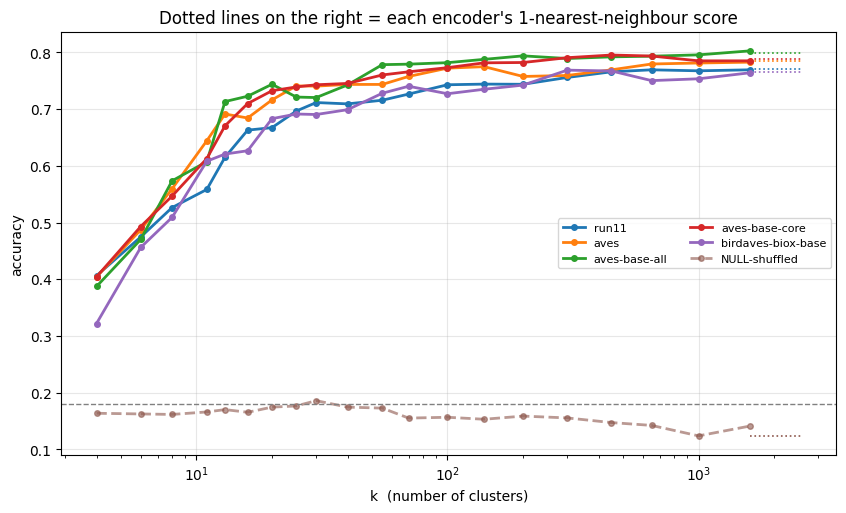

encoder                   best   at k     1-NN  difference
run11                   0.7693    650   0.7699     -0.0006
aves                    0.7828   1600   0.7843     -0.0015
aves-base-all           0.8028   1600   0.7995     +0.0032
aves-base-core          0.7954    450   0.7887     +0.0067
birdaves-biox-base      0.7688    300   0.7649     +0.0038
NULL-shuffled           0.1858     30   0.1243     +0.0615


In [2]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for e in REAL + ["NULL-shuffled"]:
    d = CEIL["encoders"][e]["vote_acc"]
    ks = sorted(int(k) for k in d)
    is_null = e == "NULL-shuffled"
    ax.plot(ks, [d[str(k)] for k in ks], "o--" if is_null else "o-",
            lw=2, ms=4, alpha=.6 if is_null else 1, label=e)
    nn = CEIL["encoders"][e]["knn1"]
    ax.hlines(nn, ks[-1], ks[-1] * 1.6, ls=":", lw=1.2,
              color=ax.lines[-1].get_color())

ax.axhline(CEIL["majority"], color="grey", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("k  (number of clusters)"); ax.set_ylabel("accuracy")
ax.set_title("Dotted lines on the right = each encoder's 1-nearest-neighbour score")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=.3)
plt.show()

print(f"{'encoder':<22}{'best':>8}{'at k':>7}{'1-NN':>9}{'difference':>12}")
for e in REAL + ["NULL-shuffled"]:
    d = CEIL["encoders"][e]
    print(f"{e:<22}{d['best_acc']:>8.4f}{d['best_k']:>7}{d['knn1']:>9.4f}"
          f"{d['best_acc'] - d['knn1']:>+12.4f}")

**Read the last column.** Every real encoder lands on its own 1-NN score to within 0.007. There is
no peak in the middle — accuracy just climbs until you stop compressing.

So **"what is the right k?" is the wrong question.** There is no natural number of groups to find;
`k` is a compression dial, and less compression always scores better.

**The one exception is the control.** `NULL-shuffled` is the same embeddings with every dimension
shuffled independently across clips — identical per-dimension statistics, relationships destroyed.
It's the *only* curve that peaks and then falls back. That shape is a free structure test you can
run on any corpus, labelled or not.

---
## 3. Second surprise: the popular criteria point the wrong way

Since we can't pick `k`, the real question is: **given the same `k`, which encoder is better?**

We have 5 encoders and we know their true ranking. Each label-free criterion also produces a
ranking. **Spearman ρ** compares two rankings: `+1` identical, `0` unrelated, `−1` exactly reversed.

Two families of criterion:

- **Compactness** — *are these blobs tight and round?* (silhouette, Calinski–Harabasz, Davies–Bouldin, gap)
- **Reproducibility** — *would I find these same groups again in birds I haven't seen?* (the stability measures)

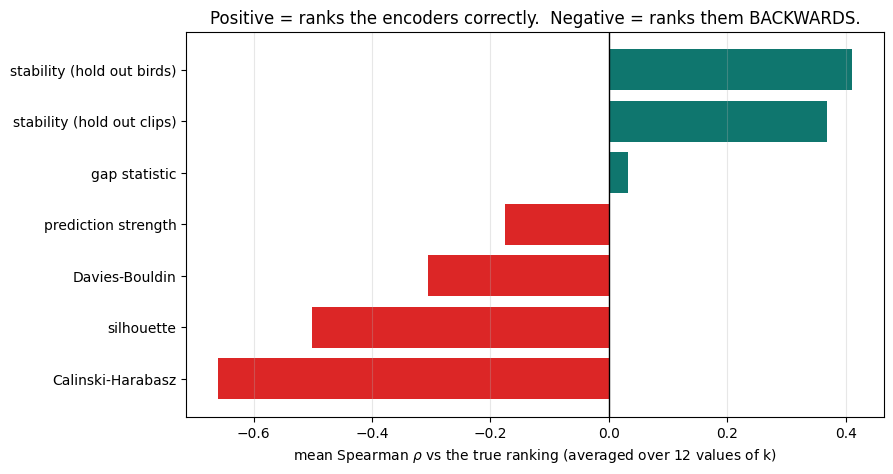

stability (hold out birds)         +0.41   correct direction at 10/12 values of k
stability (hold out clips)         +0.37   correct direction at  9/12 values of k
gap statistic                      +0.03   correct direction at  5/12 values of k
prediction strength                -0.18   correct direction at  3/12 values of k
Davies-Bouldin                     -0.30   correct direction at  1/12 values of k
silhouette                         -0.50   correct direction at  1/12 values of k
Calinski-Harabasz                  -0.66   correct direction at  1/12 values of k


In [3]:
from scipy.stats import spearmanr

KS = BLIND["ks"]
CRITS = ["stab_bird", "stab_clip", "gap", "prediction_strength",
         "neg_davies_bouldin", "silhouette", "calinski_harabasz"]
NICE = {"stab_bird": "stability (hold out birds)", "stab_clip": "stability (hold out clips)",
        "gap": "gap statistic", "prediction_strength": "prediction strength",
        "neg_davies_bouldin": "Davies-Bouldin", "silhouette": "silhouette",
        "calinski_harabasz": "Calinski-Harabasz"}

rho = {}
for c in CRITS:
    rho[c] = [spearmanr([BLIND["encoders"][e]["criteria"][c][str(k)] for e in REAL],
                        [BLIND["encoders"][e]["truth"]["vote_acc"][str(k)] for e in REAL]
                        ).statistic for k in KS]

fig, ax = plt.subplots(figsize=(9, 5))
means = {c: np.mean(v) for c, v in rho.items()}
order = sorted(means, key=means.get)
ax.barh([NICE[c] for c in order], [means[c] for c in order],
        color=["#0F766E" if means[c] > 0 else "#DC2626" for c in order])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel(r"mean Spearman $\rho$ vs the true ranking (averaged over 12 values of k)")
ax.set_title("Positive = ranks the encoders correctly.  Negative = ranks them BACKWARDS.")
ax.grid(axis="x", alpha=.3)
plt.show()

for c in reversed(order):
    n_pos = sum(1 for x in rho[c] if x > 0)
    print(f"{NICE[c]:<32}{means[c]:>+8.2f}   correct direction at {n_pos:>2}/12 values of k")

**The split is clean.** Reproducibility criteria track the truth. Compactness criteria don't just
fail — they rank the encoders **backwards**, getting the direction right at 1 of 12 values of `k`.

**Why (this is the whole mechanism).** The better encoder spreads one call type across *several*
sub-blobs instead of one tidy ball. That's exactly what lets it win at higher `k` — and exactly what
silhouette, Calinski–Harabasz and Davies–Bouldin penalise. **They score down the property that makes
a representation useful.**

**How much weight this carries:** 5 encoders whose true accuracies span only 0.052. Any single ρ is
one swap from meaningless. The claim rests on the *sign holding across k*, not on any one number.

---
## 4. The move that gets you out: ask "repeatable?" instead of "correct?"

You can't ask *is this clustering correct?* without labels. You **can** ask *would I get it again?*

Here it is, and notice no labels appear anywhere:

1. Split your 48 birds into two halves: **A** and **B**.
2. Cluster A's calls on their own. Cluster B's calls on their own.
3. Take A's cluster centres and use them to label B's points.
4. Compare that against B's own clustering.

Agreement means the structure is a property of **zebra finch calls**. Disagreement means it was a
property of **those particular birds**. This is the piece that transfers to bats.

In [4]:
# The stability calculation, run live on a small subsample so you can watch it work.
import sys
sys.path.insert(0, str(ROOT / "zfeval" / "experiments")); sys.path.insert(0, str(ROOT / "zfeval"))
import warnings; warnings.filterwarnings("ignore")
import calltype11 as C11, calltype_blindselect as BS
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

y, birds, classes = BS.cohort()
E = np.load(C11.FEAT / "ct11_aves_emb.npy")[:, 3].astype(np.float64)
X = StandardScaler().fit_transform(E)

rng = np.random.default_rng(0)
ub = np.unique(birds)
perm = rng.permutation(len(ub))
half_A, half_B = ub[perm[:len(ub)//2]], ub[perm[len(ub)//2:]]
mA = np.isin(birds, half_A)

K = 20
labA = fcluster(linkage(X[mA],  method="ward"), t=K, criterion="maxclust") - 1   # step 2
labB = fcluster(linkage(X[~mA], method="ward"), t=K, criterion="maxclust") - 1   # step 2
carried = BS.assign(X[~mA], BS.centroids(X[mA], labA, K))                        # step 3
print(f"birds A: {mA.sum()} clips   birds B: {(~mA).sum()} clips   k={K}")
print(f"agreement (ARI) between B's own clustering and A's carried over: "
      f"{adjusted_rand_score(labB, carried):.3f}")
print("  1.0 = identical | 0.0 = no better than chance (ARI is chance-corrected,")
print("  so a bigger k earns no free credit)")

birds A: 1834 clips   birds B: 1578 clips   k=20
agreement (ARI) between B's own clustering and A's carried over: 0.489
  1.0 = identical | 0.0 = no better than chance (ARI is chance-corrected,
  so a bigger k earns no free credit)


---
## 5. The shuffle test: is there anything there at all?

Clustering **always** returns clusters. Run k-means on pure noise and you get `k` tidy groups. So
before believing any score, you need to know what *"nothing there"* looks like.

Shuffle each of the 768 dimensions independently across clips. Every dimension keeps its exact
distribution; the relationships between them are destroyed. Then run the identical pipeline.

In [5]:
K_FIX = "30"
print(f"{'criterion':<32}{'real (median)':>15}{'shuffled':>12}   verdict")
for c in CRITS:
    r = np.median([BLIND["encoders"][e]["criteria"][c][K_FIX] for e in REAL])
    n = BLIND["encoders"]["NULL-shuffled"]["criteria"][c][K_FIX]
    sep = abs(r - n) / (abs(r) + abs(n) + 1e-12)
    print(f"{NICE[c]:<32}{r:>15.4f}{n:>12.4f}   "
          f"{'separates' if sep > .5 else 'CANNOT TELL THEM APART'}")

criterion                         real (median)    shuffled   verdict
stability (hold out birds)               0.4890      0.0014   separates
stability (hold out clips)               0.5484      0.0016   separates
gap statistic                            1.9118      1.4534   CANNOT TELL THEM APART
prediction strength                      0.1931      0.0397   separates
Davies-Bouldin                          -2.5508    -12.1315   separates
silhouette                               0.0853     -0.0022   separates
Calinski-Harabasz                      101.4514      1.9351   separates


Stability separates real from shuffled by roughly **350×**. The **gap statistic cannot tell them
apart at all** — which also explains why it looked perfect in section 2: it was just naming the
biggest `k` on offer every time.

---
## 6. So: the protocol for a species with no labels

| # | Do this | Because |
|---|---|---|
| 1 | Shuffle your own feature columns, run everything twice | Only free floor you get |
| 2 | Plot your readout against `k` on a log axis, out to 1-NN | Rising-to-ceiling = structure. Peak-then-fall = nothing there |
| 3 | Fix `k` from your **budget**, report a curve, never a single `k` | There is no natural `k` to discover |
| 4 | Rank encoders by **held-out-individual stability** at matched `k`, band `k ≈ 13–140` | The only family that tracked truth here |
| 5 | Do **not** use silhouette / CH / Davies–Bouldin / gap to choose between representations | Three rank backwards; the fourth can't tell real from noise |

**What this does NOT license.** Stability's own argmax lands at `k = 4–25`, below the 11 human call
types. That is *not* evidence zebra finches have 8 call types — ARI declines with `k` for generic
combinatorial reasons, so that peak is biased toward coarseness by construction.

A second calibration was attempted (bird identity as the target) and came back **underpowered —
no conclusion**. Section 7 shows why, because the way it failed is worth knowing.

---
## 7. A null result, and how to spot one

The second calibration made bird identity the target instead of call type. The criteria produced
eye-catching numbers — compactness suddenly looked *best*. Then the resolution check killed it.

**Always ask: can my measurement tell these things apart at all?**

In [6]:
ID = D / "identity_blindselect.json"
if ID.exists():
    R = json.loads(ID.read_text())
    accs = {e: R["encoders"][e]["truth"]["vote_acc"]["450"] for e in REAL}
    for e, a in sorted(accs.items(), key=lambda kv: -kv[1]):
        print(f"  {e:<22}{a:.4f}")
    top4 = sorted(accs.values(), reverse=True)[:4]
    print(f"\ntop four span {max(top4) - min(top4):.4f}")
    print("bootstrap 95% CI width per encoder was ~0.031 -> the top four are NOT distinguishable")
    print("\nThe honest ceiling: Spearman rho of the TRUE accuracy against ITSELF under resampling")
    print("  median +0.80, 95% CI [+0.15, +1.00]")
    print("  -> a PERFECT criterion could score +0.15 here.")
    print("  -> every observed rho (+0.25, +0.26, +0.57, +0.58) sits inside that interval,")
    print("     indistinguishable from perfection and from each other. No conclusion.")
else:
    print("run zfeval/experiments/identity_blindselect.py first")

  aves-base-all         0.5923
  run11                 0.5917
  aves-base-core        0.5856
  aves                  0.5853
  birdaves-biox-base    0.5352

top four span 0.0070
bootstrap 95% CI width per encoder was ~0.031 -> the top four are NOT distinguishable

The honest ceiling: Spearman rho of the TRUE accuracy against ITSELF under resampling
  median +0.80, 95% CI [+0.15, +1.00]
  -> a PERFECT criterion could score +0.15 here.
  -> every observed rho (+0.25, +0.26, +0.57, +0.58) sits inside that interval,
     indistinguishable from perfection and from each other. No conclusion.


**The lesson that generalises past this page:** measure your instrument's resolution *before*
comparing anything with it. Correlating the truth against *itself* under resampling gives you the
ceiling any criterion could reach. If that ceiling is low, every number you're about to compare is
noise — no matter how clean the pattern looks.

---
### Where this came from

| what | where |
|---|---|
| criteria × k × encoders | `zfeval/experiments/calltype_blindselect.py` |
| k pushed to 1600 + 1-NN limit | `zfeval/experiments/calltype_kceiling.py` |
| the underpowered second calibration | `zfeval/experiments/identity_blindselect.py` |
| resolution / power check | `zfeval/experiments/identity_blindselect_power.py` |
| written up | knowledge finding `050` |